In [8]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import shap

# Generate a random dataset
np.random.seed(42)
n_samples = 500
n_features = 5

# Create feature names
feature_names = [f'feature_{i}' for i in range(n_features)]

# Generate random features
X = pd.DataFrame(np.random.rand(n_samples, n_features), columns=feature_names)

# Generate a binary target variable
y = np.random.choice([0, 1], size=n_samples)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a RandomForest model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]  # Probability of class 1

# Convert to DataFrame
df = X_test.copy()
df["y_pred"] = y_pred
df["y_proba"] = y_proba



# SHAP Explanation
explainer = shap.Explainer(model, X_test)
# Extract SHAP values for class 1 (index 1)
shap_values = explainer(X_test).values[:, :, 1]  # Extract only class 1 SHAP values

# Convert to DataFrame
shap_df = pd.DataFrame(shap_values, columns=feature_names)

# Identify the most relevant feature for each row
df["most_relevant_feature"] = shap_df.abs().idxmax(axis=1)

# Display sample
print(df.head())


     feature_0  feature_1  feature_2  feature_3  feature_4  y_pred  y_proba  \
361   0.774654   0.661371   0.185196   0.174109   0.098396       1     0.56   
73    0.386103   0.961191   0.905351   0.195791   0.069361       0     0.45   
374   0.817785   0.213511   0.505853   0.840703   0.732802       0     0.32   
155   0.149917   0.229251   0.722253   0.720037   0.641148       1     0.57   
104   0.594131   0.380891   0.969914   0.842119   0.838329       0     0.47   

    most_relevant_feature  
361                   NaN  
73              feature_4  
374                   NaN  
155                   NaN  
104                   NaN  


In [7]:
df = pd.DataFrame(df)
df.head(20)

,feature_0,feature_1,feature_2,feature_3,feature_4,y_pred,y_proba,most_relevant_feature
361,0.774654,0.661371,0.185196,0.174109,0.098396,1,0.56,NaN
73,0.386103,0.961191,0.905351,0.195791,0.069361,0,0.45,feature_1
374,0.817785,0.213511,0.505853,0.840703,0.732802,0,0.32,NaN
155,0.149917,0.229251,0.722253,0.720037,0.641148,1,0.57,NaN
104,0.594131,0.380891,0.969914,0.842119,0.838329,0,0.47,NaN
394,0.024192,0.831697,0.273071,0.518079,0.298726,0,0.43,NaN
377,0.461557,0.009332,0.246679,0.726462,0.991810,0,0.45,NaN
124,0.184521,0.209349,0.370472,0.484523,0.618255,1,0.67,NaN
68,0.491616,0.473472,0.173202,0.433852,0.398505,1,0.68,feature_0
450,0.093857,0.909627,0.669200,0.829287,0.878979,1,0.51,NaN


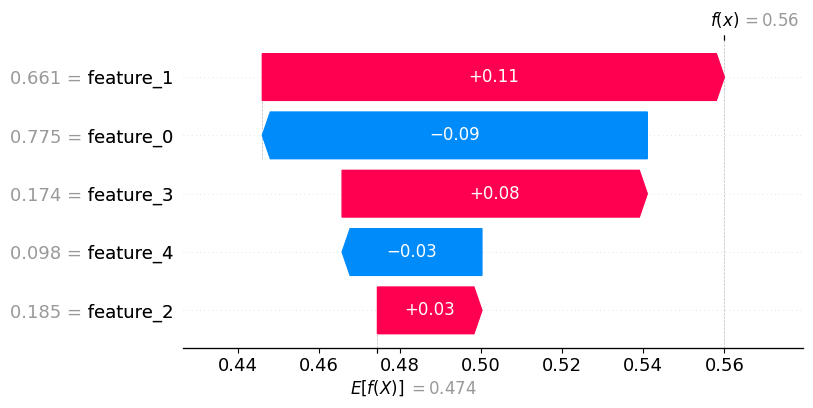

In [9]:
shap.waterfall_plot(shap.Explanation(values=shap_values[0], base_values=explainer.expected_value[1], data=X_test.iloc[0]))


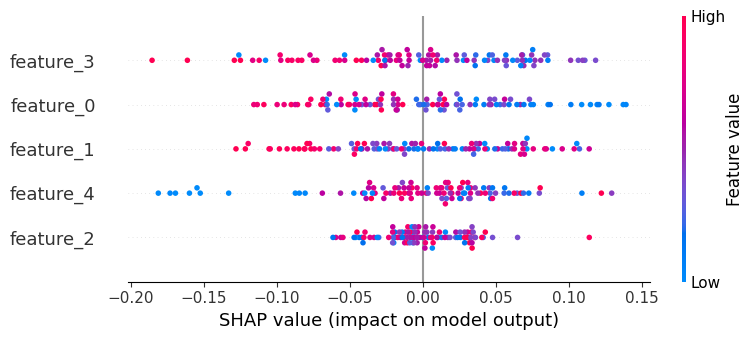

In [10]:
shap.summary_plot(shap_values, X_test)
